## EU Wayfair BSR Share 분석

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
sql = f"""
select * from mart.way_eu_bsr
where page_label='p.1 (1~48)'
"""

df = bqclient.query(sql).to_dataframe()

In [11]:
print(df)

      country    category is_zinus_prod         sku  \
0          UK  mattresses             N  U110295396   
1          UK  mattresses             N  U110295396   
2          UK  mattresses             N  U110295396   
3          UK  mattresses             N  U110295396   
4          UK  mattresses             N  U110295396   
...       ...         ...           ...         ...   
78907      DE       sofas             N  D001655052   
78908      DE       sofas             N  D001655052   
78909      DE       sofas             N  D001655052   
78910      DE       sofas             N  D001655052   
78911      DE       sofas             N  D001655052   

                                             product_url  \
0                                                   None   
1                                                   None   
2                                                   None   
3                                                   None   
4                                      

In [36]:
df1 = df.copy()

In [38]:
df_uk = df1[(df1['country']=='UK') & (df1['category']=='beds')].copy()

# 주별 집계
zinus_weekly = (
    df_uk.groupby('yr_week')
      .agg(
          total_count=('is_zinus_prod', 'count'),
          zinus_count=('is_zinus_prod', lambda x: (x == 'Y').sum())
      )
      .reset_index()
)

# 점유율 계산
zinus_weekly['zinus_share'] = zinus_weekly['zinus_count'] / zinus_weekly['total_count']
zinus_weekly['zinus_share_pct'] = zinus_weekly['zinus_share'] * 100  # 퍼센트 표시

print(zinus_weekly)

    yr_week  total_count  zinus_count  zinus_share  zinus_share_pct
0   Y24 W50           96           44     0.458333        45.833333
1   Y24 W51          336          151     0.449405        44.940476
2   Y24 W52          336          144     0.428571        42.857143
3   Y25 W01          336          138     0.410714        41.071429
4   Y25 W02          288          130     0.451389        45.138889
5   Y25 W03          336          138     0.410714        41.071429
6   Y25 W04          336          116     0.345238        34.523810
7   Y25 W05          336          141     0.419643        41.964286
8   Y25 W06          336          136     0.404762        40.476190
9   Y25 W07          336          134     0.398810        39.880952
10  Y25 W08          336          130     0.386905        38.690476
11  Y25 W09          336          132     0.392857        39.285714
12  Y25 W10          336           95     0.282738        28.273810
13  Y25 W11          288           88     0.3055

In [40]:
TOP_N = 10

# 0) UK 필터 + Zinus 지정
df_uk = df1[df1['country'] == 'UK'].copy()

# is_zinus_prod == 'Y' 인 행은 브랜드를 'Zinus'로 통일
df_uk.loc[df_uk['is_zinus_prod'] == 'Y', 'brand'] = 'Zinus'

# 1) CATEGORY x BRAND 별 행 수
brand_counts = (
    df_uk.groupby(['category', 'brand'], dropna=False)
         .size()
         .reset_index(name='brand_count')
)

# 2) CATEGORY 별 전체 행 수
totals = (
    brand_counts.groupby('category', as_index=False)['brand_count']
                .sum()
                .rename(columns={'brand_count': 'total_count'})
)

# 3) 병합 후 카테고리 내 랭크 → Top10 이외 Others 처리
brand_cat = brand_counts.merge(totals, on='category', how='left')
brand_cat['rank_in_cat'] = brand_cat.groupby('category')['brand_count'] \
                                    .rank(method='first', ascending=False)
brand_cat['brand_adj'] = np.where(brand_cat['rank_in_cat'] <= TOP_N,
                                  brand_cat['brand'], 'Others')

# 4) Others 포함 재집계 + 점유율
result = (
    brand_cat.groupby(['category', 'brand_adj'], as_index=False)
             .agg(brand_count=('brand_count', 'sum'),
                  total_count=('total_count', 'first'))
)
result['share'] = result['brand_count'] / result['total_count']
result['share_pct'] = (result['share'] * 100).round(1)

# 보기 좋게: 카테고리별 정렬 (Others는 항상 마지막)
result['_is_others'] = (result['brand_adj'] == 'Others').astype(int)
result = result.sort_values(['category', '_is_others', 'share'], ascending=[True, True, False]) \
               .drop(columns=['_is_others'])

# 출력 (카테고리별 Top10 + Others)
for cat, sub in result.groupby('category', sort=False):
    print(f"\n=== {cat} — Top {TOP_N} + Others (UK, row-based share) ===")
    print(sub[['brand_adj', 'brand_count', 'total_count', 'share_pct']].to_string(index=False))



=== beds — Top 10 + Others (UK, row-based share) ===
      brand_adj  brand_count  total_count  share_pct
          Zinus         3421        13152       26.0
      Yaheetech         1612        13152       12.3
 Zipcode Design         1324        13152       10.1
       Fernleaf         1022        13152        7.8
    Three Posts          756        13152        5.7
   Latitude Run          508        13152        3.9
  Ebern Designs          452        13152        3.4
     Wade Logan          433        13152        3.3
Brambly Cottage          370        13152        2.8
    Etta Avenue          313        13152        2.4
         Others         2941        13152       22.4

=== mattresses — Top 10 + Others (UK, row-based share) ===
                 brand_adj  brand_count  total_count  share_pct
               White Noise         4158        13152       31.6
                   Novilla         3041        13152       23.1
             Wayfair Sleep         2098        13152      

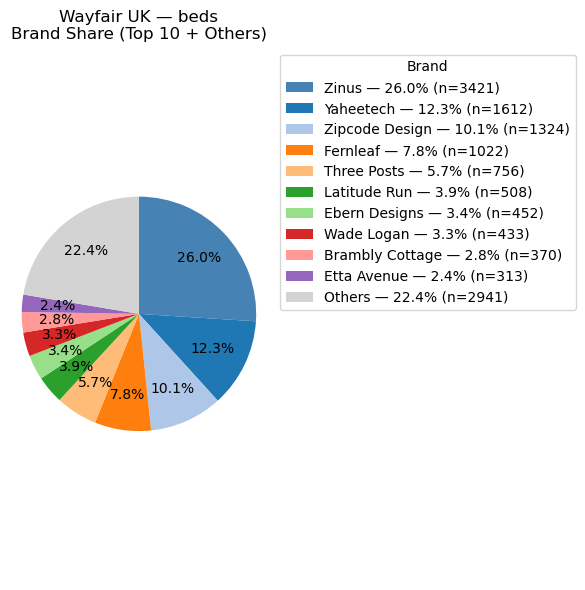

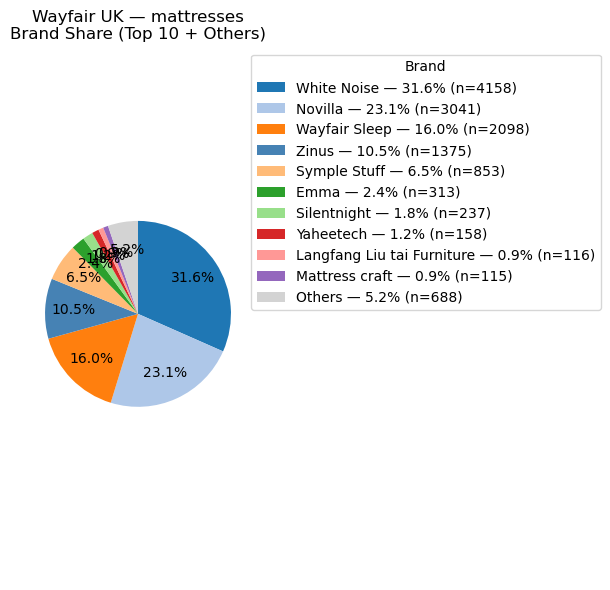

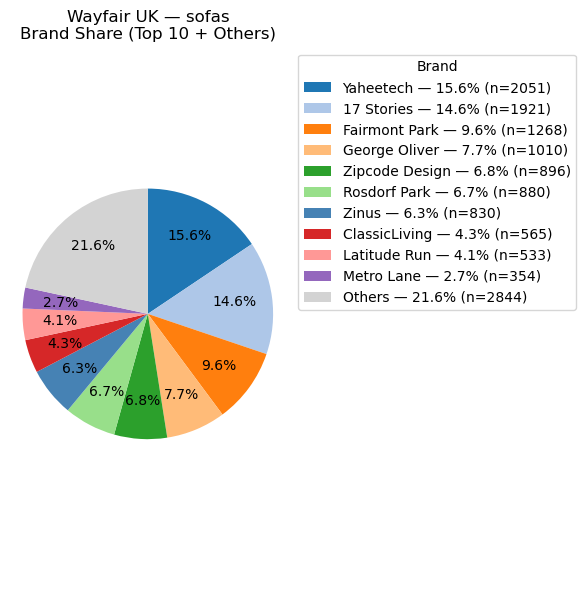

In [42]:
# ============================================
# UK의 CATEGORY별 Top10+Others 파이차트 (row-based share)
# - 바로 이전 셀에서 만든 `result`(category, brand_adj, brand_count, total_count, share, share_pct)를 사용
# - 카테고리마다 개별 파이차트 출력
# ============================================

if 'result' not in globals():
    raise RuntimeError("`result` 데이터프레임이 없습니다. 먼저 Top10+Others를 계산하는 셀을 실행하세요.")

# 카테고리 순서 고정(원하는 경우 정렬/선택 가능)
cats = list(result['category'].dropna().unique())

for cat in cats:
    sub = result[result['category'] == cat].copy()
    if sub.empty:
        continue

    # Others를 항상 마지막에, 나머지는 점유율 내림차순
    sub['_is_others'] = (sub['brand_adj'] == 'Others').astype(int)
    sub = sub.sort_values(by=['_is_others', 'share'], ascending=[True, False]).drop(columns=['_is_others'])

    labels = sub['brand_adj'].tolist()
    sizes  = sub['share'].tolist()  # 비중(0~1)
    pct    = sub['share_pct'].tolist()
    counts = sub['brand_count'].tolist()

    # 색상 매핑: Others=lightgrey, Zinus=steelblue, 나머지는 tab20 순환
    tab20 = list(plt.cm.tab20.colors)
    colors = []
    k = 0
    for b in labels:
        if b == 'Others':
            colors.append('lightgrey')
        elif b == 'Zinus':
            colors.append('steelblue')
        else:
            colors.append(tab20[k % len(tab20)])
            k += 1

    # 파이차트
    fig, ax = plt.subplots(figsize=(6, 6))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,                 # 라벨은 범례로
        autopct="%.1f%%",            # 웨지 내부 %표시
        startangle=90,
        counterclock=False,
        pctdistance=0.7
    )
    for w, c in zip(wedges, colors):
        w.set_facecolor(c)

    ax.axis('equal')  # 동그랗게
    ax.set_title(f"Wayfair UK — {cat}\nBrand Share (Top 10 + Others)")

    # 범례: Brand — XX.X% (n=count)
    legend_labels = [f"{b} — {p:.1f}% (n={n})" for b, p, n in zip(labels, pct, counts)]
    ax.legend(wedges, legend_labels, title="Brand", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


In [64]:
df1 = df.copy()

In [66]:
print(df1)

      country    category is_zinus_prod         sku  \
0          UK  mattresses             N  U110295396   
1          UK  mattresses             N  U110295396   
2          UK  mattresses             N  U110295396   
3          UK  mattresses             N  U110295396   
4          UK  mattresses             N  U110295396   
...       ...         ...           ...         ...   
78907      DE       sofas             N  D001655052   
78908      DE       sofas             N  D001655052   
78909      DE       sofas             N  D001655052   
78910      DE       sofas             N  D001655052   
78911      DE       sofas             N  D001655052   

                                             product_url  \
0                                                   None   
1                                                   None   
2                                                   None   
3                                                   None   
4                                      

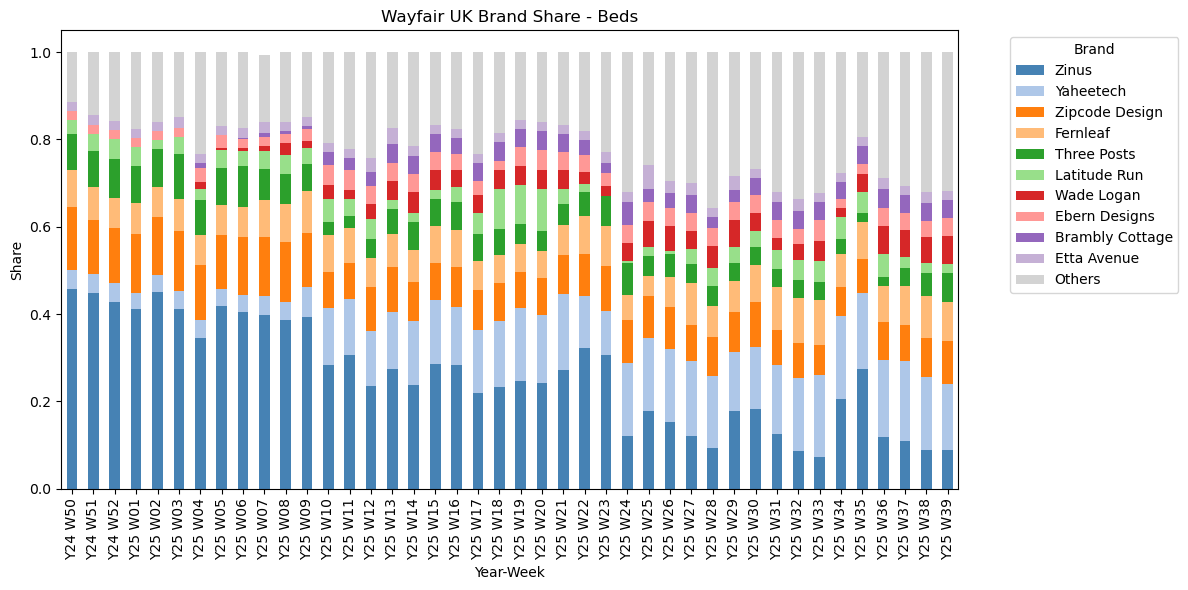

In [83]:
# === 0. 전처리: 지누스 표시 ===
df_uk_beds = df1[(df1['country']=='UK') & (df1['category']=='beds')].copy()
df_uk_beds.loc[df_uk_beds['is_zinus_prod'] == 'Y', 'brand'] = 'Zinus'

# === 1. 주별, 브랜드별 row 개수 ===
weekly_brand_counts = (
    df_uk_beds.groupby(['yr_week', 'brand'])
      .size()
      .reset_index(name='brand_count')
)

# === 2. 주별 전체 row 개수 ===
weekly_total = (
    df_uk_beds.groupby('yr_week')
      .size()
      .reset_index(name='total_count')
)

# === 3. merge 해서 점유율 계산 ===
weekly_brand_counts = weekly_brand_counts.merge(weekly_total, on='yr_week')
weekly_brand_counts['share'] = weekly_brand_counts['brand_count'] / weekly_brand_counts['total_count']

# === 4. 전체 기간 합산 후 Top 10 브랜드 선정 ===
top_brands = (
    weekly_brand_counts.groupby('brand')['brand_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# === 5. Top 10 이외는 Others로 변환 ===
weekly_brand_counts['brand_adj'] = weekly_brand_counts['brand'].where(
    weekly_brand_counts['brand'].isin(top_brands),
    'Others'
)

# === 6. 주별 다시 집계 (Others 포함) ===
weekly_top = (
    weekly_brand_counts.groupby(['yr_week', 'brand_adj'])
    .agg({'brand_count': 'sum', 'total_count': 'first'})
    .reset_index()
)
weekly_top['share'] = weekly_top['brand_count'] / weekly_top['total_count']

# === 7. 피벗 테이블 ===
pivot_df = weekly_top.pivot(index='yr_week', columns='brand_adj', values='share').fillna(0)

# === 8'. 전체 비중 기준 컬럼 순서 재정렬 (Zinus 아래, Others 위, 나머지는 비중 내림차순) ===
# 기간 전체에서의 브랜드 비중 계산: sum(brand_count) / sum(total_count)
brand_total = (
    weekly_top.groupby('brand_adj')
    .agg(brand_count_sum=('brand_count', 'sum'),
         total_count_sum=('total_count', 'sum'))
    .assign(overall_share=lambda d: d['brand_count_sum'] / d['total_count_sum'])
    .reset_index()
)

# 컬럼 후보: pivot_df에 실제 존재하는 브랜드만
present_cols = set(pivot_df.columns)
brand_total = brand_total[brand_total['brand_adj'].isin(present_cols)]

# Others, Zinus는 별도 처리하고, 나머지는 overall_share 내림차순
others_present = 'Others' in present_cols
zinus_present  = 'Zinus'  in present_cols

# 나머지(= Others/Zinus 제외) 브랜드들 정렬
middle_order = (
    brand_total[
        ~brand_total['brand_adj'].isin(['Others', 'Zinus'])
    ]
    .sort_values('overall_share', ascending=False)['brand_adj']
    .tolist()
)

ordered_cols = []
if zinus_present:
    ordered_cols.append('Zinus')       # 스택 맨 아래
ordered_cols.extend([c for c in middle_order if c not in ordered_cols])
if others_present:
    ordered_cols.append('Others')      # 스택 맨 위

# 재정렬 적용
pivot_df = pivot_df[ordered_cols]

# === 9'. 색상 지정 (Others 회색, Zinus 파란색, 나머지는 tab20 순서대로) ===
default_colors = plt.cm.tab20.colors
color_map = {}
for i, col in enumerate(pivot_df.columns):
    if col == 'Others':
        color_map[col] = 'lightgrey'
    elif col == 'Zinus':
        color_map[col] = 'steelblue'
    else:
        color_map[col] = default_colors[i % len(default_colors)]

colors = [color_map[c] for c in pivot_df.columns]

# === 10. 누적 막대 그래프 ===
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)

plt.title('Wayfair UK Brand Share - Beds')
plt.xlabel('Year-Week')
plt.ylabel('Share')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

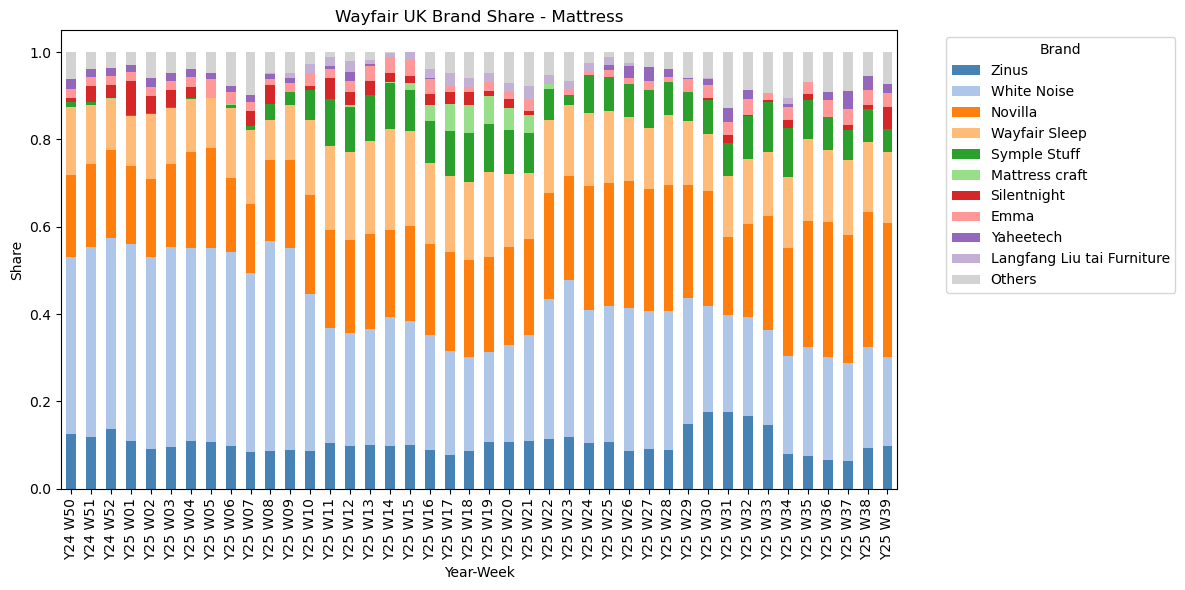

In [85]:
# === 0. 전처리: 지누스 표시 ===
df_uk_matt = df1[(df1['country']=='UK') & (df1['category']=='mattresses')].copy()
df_uk_matt.loc[df_uk_matt['is_zinus_prod'] == 'Y', 'brand'] = 'Zinus'  # <-- df_uk_beds → df_uk_matt 로 수정

# === 1. 주별, 브랜드별 row 개수 ===
weekly_brand_counts = (
    df_uk_matt.groupby(['yr_week', 'brand'])
      .size()
      .reset_index(name='brand_count')
)

# === 2. 주별 전체 row 개수 ===
weekly_total = (
    df_uk_matt.groupby('yr_week')
      .size()
      .reset_index(name='total_count')
)

# === 3. merge 해서 점유율 계산 ===
weekly_brand_counts = weekly_brand_counts.merge(weekly_total, on='yr_week')
weekly_brand_counts['share'] = weekly_brand_counts['brand_count'] / weekly_brand_counts['total_count']

# === 4. 전체 기간 합산 후 Top 10 브랜드 선정 ===
top_brands = (
    weekly_brand_counts.groupby('brand')['brand_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# === 5. Top 10 이외는 Others로 변환 ===
weekly_brand_counts['brand_adj'] = weekly_brand_counts['brand'].where(
    weekly_brand_counts['brand'].isin(top_brands),
    'Others'
)

# === 6. 주별 다시 집계 (Others 포함) ===
weekly_top = (
    weekly_brand_counts.groupby(['yr_week', 'brand_adj'])
    .agg({'brand_count': 'sum', 'total_count': 'first'})
    .reset_index()
)
weekly_top['share'] = weekly_top['brand_count'] / weekly_top['total_count']

# === 7. 피벗 테이블 ===
pivot_df = weekly_top.pivot(index='yr_week', columns='brand_adj', values='share').fillna(0)

# === 8'. 전체 비중 기준 컬럼 순서 재정렬 (Zinus 아래, Others 위, 나머지는 비중 내림차순) ===
brand_total = (
    weekly_top.groupby('brand_adj')
    .agg(brand_count_sum=('brand_count', 'sum'),
         total_count_sum=('total_count', 'sum'))
    .assign(overall_share=lambda d: d['brand_count_sum'] / d['total_count_sum'])
    .reset_index()
)

present_cols = set(pivot_df.columns)
brand_total = brand_total[brand_total['brand_adj'].isin(present_cols)]

others_present = 'Others' in present_cols
zinus_present  = 'Zinus'  in present_cols

middle_order = (
    brand_total[
        ~brand_total['brand_adj'].isin(['Others', 'Zinus'])
    ]
    .sort_values('overall_share', ascending=False)['brand_adj']
    .tolist()
)

ordered_cols = []
if zinus_present:
    ordered_cols.append('Zinus')
ordered_cols.extend([c for c in middle_order if c not in ordered_cols])
if others_present:
    ordered_cols.append('Others')

pivot_df = pivot_df[ordered_cols]

# === 9'. 색상 지정 ===
default_colors = plt.cm.tab20.colors
color_map = {}
for i, col in enumerate(pivot_df.columns):
    if col == 'Others':
        color_map[col] = 'lightgrey'
    elif col == 'Zinus':
        color_map[col] = 'steelblue'
    else:
        color_map[col] = default_colors[i % len(default_colors)]

colors = [color_map[c] for c in pivot_df.columns]

# === 10. 누적 막대 그래프 ===
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)

plt.title('Wayfair UK Brand Share - Mattress')
plt.xlabel('Year-Week')
plt.ylabel('Share')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()